<center>
<img src="https://raw.githubusercontent.com/FUlyankin/r_probability/master/end_seminars_2020/sem08/real_expect.png" width="500">

# Андан на экономе: домашнее задание 4
</center>


> Если орел, я выиграла. Если решка, ты проиграл.

$\qquad$ $\qquad$ $\qquad$ $\qquad$  **[Рейчел из Друзей](https://www.youtube.com/watch?v=TV9ghItJ2Ms)**

**ФИО:** Гаврин Глеб Юрьевич

## Общая информация

__Дата выдачи:__ 20.05.2024

__Дедлайн:__ 23:59MSK 10.06.2024

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 100 баллов. За каждый день просрочки после мягкого дедлайна снимается 10 баллов. После жёсткого дедлайна работы не принимаются. Даже при опозданиии на одну секунду. Сдавайте работы заранее.

Мягкий дедлайн можно отодвинуть без потери баллов на 1,2 или 3 дня. Суммарно для откладывания в запасе есть три дня. Можно отодвинуть один дедлайн на три дня, а можно три дедлайна подвинуть на один день. Распоряжаться этими днями студент может как угодно. Жёсткий дедлайн, при этом, не меняется. Если такое произошло, нужно сообщить о сдвиге при сдаче работы.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Любой из студентов может быть вызван на защиту любого домашнего задания. В таком случае итоговая оценка студента определяется в результате защиты.

> За отсутствие названий графиков и подписей к осям могут снижаться баллы. Все картинки должны быть самодостаточны и визуально удобны для восприятия, так чтобы не нужно было смотреть ваш код или знать задание, чтобы понять что на них изображено. Выводы должны быть релевантными. Не забывайте их писать. Если в вопросе требуется ответ словами, а его нет, вы будете терять довольно много баллов.

## Формат сдачи

Сам ноутбук называйте в формате hw-02-USERNAME.ipynb, где USERNAME — ваши фамилия и имя на латинице. Задание сдаётся в anytask.

In [56]:
import numpy as np
import pandas as pd
import math
import scipy.stats as sts
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import plotly.graph_objects as go

In [3]:
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = 8, 5
plt.rcParams['font.size'] = 12
plt.rcParams['savefig.format'] = 'pdf'
sns.set_style('darkgrid')

## Часть 1: обязательная 

За эту часть можно получить 100 баллов.

## Задача №4: Не подглядывать! (40 баллов)

<img src="https://github.com/hse-econ-data-science/andan_2023/blob/main/hw/hw04/images/trump.png?raw=true" width="500" align='left'>

На американских выборах 2020 года в некоторых штатах проходила очень конкурентная борьба между кандидатами. По мере подсчета голосов перевес в голосах склонялся то в пользу демократов, то в пользу республиканцев. И вот, в один из таких моментов, когда чаша весов склонилась в пользу республиканцев, Д. Трамп написал в твиттер "stop the count!", что означало призыв к остановке подсчета голосов. 

_Здесь у вас мог возникнуть вопрос, и зачем нам это?_ 

Ответ очень прост. В этой ситуации всем очевидно, что призыв Трампа не мог быть осуществлен, то есть прерывать подсчет голосов раньше времени кажется довольно глупым способом выявления победителя. И вот абсолютно такой же способ принятия решения есть и в А/Б-тестах, только теперь многим аналитикам он уже кажется не столь очевидным, что приводит к существенным ошибкам в заключении выводов. 

_Решив эту задачу, мы познакомимся с такой проблемой подробнее и поймем, как не стоит делать, когда вы запускаете А/Б-тест._

Чтобы понять, в чем же именно заключается проблема, мы с вами будем проводить симуляции А/Б-тестов. Это когда мы генерируем данные уже со знаниями, как эти данные устроены. А затем, запуская процедуру проверки гипотез над такими симулированными данными, мы будем оценивать, что происходит на практике (при запуске А/Б-теста).

На практике же всегда неизвестно, как устроены данные, и проводя А/Б-тест мы пытаемся зафиксировать различия. Еще раз, здесь же мы будем знать об устройстве данных, а затем будем смотреть на поведение А/Б-теста, то есть как будто бы смотреть на тест с обратной стороны. 

_Перед тем как идти дальше, остановитесь здесь и еще раз зафиксируйте это!_

__а) [10 баллов]  Подсчет размера выборки для А/Б-теста__

Предположим, что вы хотите провести А/Б-тест внутри вашего приложения. Вы выбрали некоторую метрику $X$ – случайную величину из нормального распределения с мат. ожиданием $100$ у.е. и стандартным отклонением $40$ у.е – это ваш бейзлайн (группа А). Рассчитайте, сколько дней вам нужно крутить такой А/Б-тест, если:

1. Вы ожидаете получить минимальный размер эффекта в $5$ у.е.;
2. Вы хотите зафиксировать ошибку первого рода на уровне $\alpha=5\%$, а ошибку второго рода на уровне $\beta=20\%$;
3. Вы точно знаете, что в группе Б стандартное отклонение метрики составляет также $20$ у.е.
4. Посещаемость вашего приложения ежедневно составляет $200$ пользователей, и вы готовы раскатить тест на $100\%$ трафика.

Формула для расчета числа наблюдений _для одной группы_:

$$
n_{\text{one group}} = \frac{(\sigma_A^2 + \sigma_B^2) \cdot (z_{1-\frac{\alpha}{2}} + z_{1-\beta})^2}{MDE^2},
$$

__Подсказка:__ Помните, что после получения общего числа наблюдений вам нужно выразить это в дни! Вы должны получить целое число. Также будьте аккуратны с подсчетом трафика и кол-ва наблюдений – обратите внимание, со скольким числом групп вы работаете!

In [74]:
import random
#random.seed(77) # для воспроизводимости

In [32]:
MDE = 5
alpha = 0.05
beta = 0.2
sigma_b = 20
sigma_a = 40

za = sts.norm.ppf(1 - alpha/2)
zb = sts.norm.ppf(1 - beta)

n1 = ((sigma_a**2 + sigma_b**2) * (za + zb)**2) / (MDE**2) #необходимое число наблюдений для 1 группы
n = n1 * 2 # так как нам нужно 2 группы - контрольная и тестовая

days = n / 200 # необходимое кол-во дней, так как в день 200 пользователей
print(f'Чтобы провести такой А/Б тест, нужно {math.ceil(days)} дней') # округляем в большую сторону, так как нам нужны полные дни


Чтобы провести такой А/Б тест, нужно 7 дней


__б) [20 баллов] Симуляция А/Б-теста__

Теперь нам нужно запустить А/Б-тест. Для этого:

1. Сгенерируйте выборку данных из нормального распределения для группы А и Б в конкретный один день. Считайте, что в группе Б математическое ожидание составляет $105$ у.е., то есть с учетом размера вашего минимального ожидаемого эффекта из предыдущего пункта.

In [25]:
group_a = np.random.normal(loc = 100, scale = 40, size=100)
group_b = np.random.normal(loc = 105, scale = 40, size=100)

2. Теперь представим, что наш тест был запущен $X$ дней. Напишите функцию, которая за этот период теста собирает в `DataFrame` следующие данные на каждый день теста: 
    1. среднее метрики в группе А
    2. среднее метрики в группе Б
    3. p-value, посчитанное с помощью t-test – можно воспользоваться встроенной функцией `scipy.stats.ttest_ind`
    
    Соберите `DataFrame` для $X=50$.
    
__Подсказка:__ Среднее для 1-го дня должно считаться по пользователям, пришедших в первый день, для второго дня – по пользователям, пришедшим в первый и второй день и т.д. То есть накопленным итогом за каждый день теста.

In [102]:
group_a_j = np.random.normal(loc = 100, scale = 40, size=100)
group_b_j = np.random.normal(loc = 105, scale = 40, size=100)

In [122]:
def build_dataframe(period):
    df_days_means = pd.DataFrame(columns=['День', 'Среднее в группе А', 'Среднее в группе Б', 'p-value'])
    gr_a_cum = np.array([])
    gr_b_cum = np.array([])
    for day in range(1, period+1):
        group_a_i = np.random.normal(loc = 100, scale = sigma_a, size=100)
        group_b_i = np.random.normal(loc = 105, scale = sigma_b, size=100)

        #group_a_i_mean = group_a_i.mean()
        #group_b_i_mean = group_b_i.mean()

        gr_a_cum = np.append(gr_a_cum, group_a_i)
        gr_b_cum = np.append(gr_b_cum, group_b_i)
        t_statistic, p_value = ttest_ind(gr_a_cum, gr_b_cum, equal_var=True)


        gr_a_cum_mean = gr_a_cum.mean()
        gr_b_cum_mean = gr_b_cum.mean()

        

        df_days_means.loc[day] = [day, gr_a_cum_mean, gr_b_cum_mean, p_value]
    return df_days_means    
        


In [123]:
df_ab = build_dataframe(50)
df_ab.head()

,День,Среднее в группе А,Среднее в группе Б,p-value
1,1.0,96.793489,104.592324,0.079294
2,2.0,98.097304,105.103824,0.024420
3,3.0,99.430224,105.829218,0.017514
4,4.0,98.127646,106.279656,0.000429
5,5.0,98.947031,105.524388,0.001181


In [124]:
round(df_ab['p-value'].min(), 3)

0.0

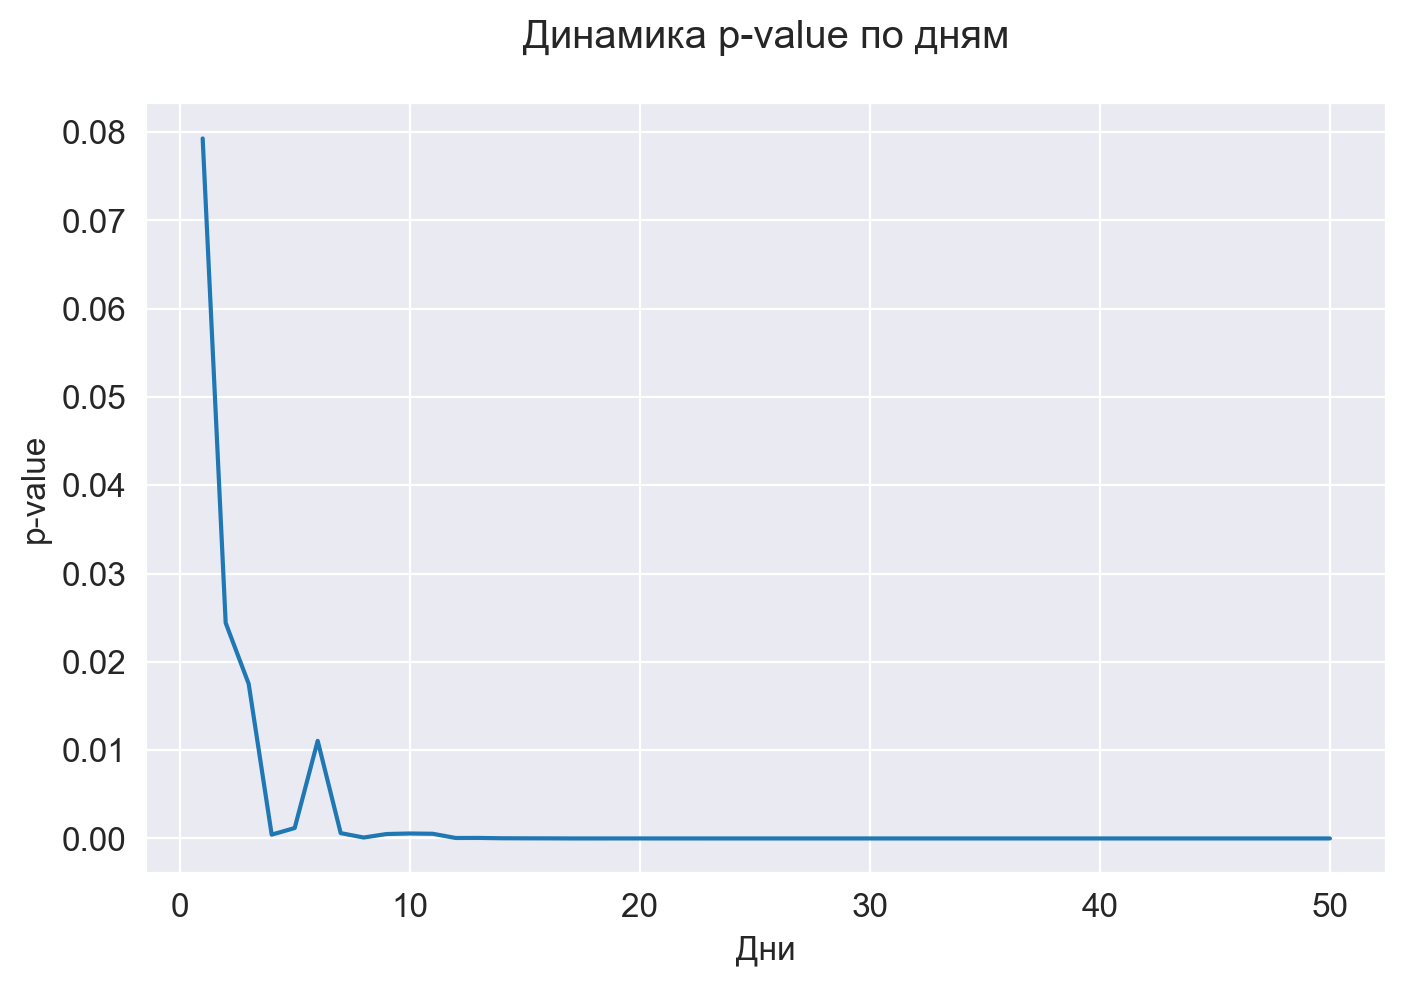

In [125]:
plot_pvalue = df_ab['p-value']

ax = plot_pvalue.plot()
ax.set_xlabel("Дни")
ax.set_ylabel("p-value")
plt.title("Динамика p-value по дням", pad=20)
plt.show()

In [126]:
#Как мы видим, начиная с 5го дня p-value < 0.05, значит начиная с 5-го дня различия приобретают стат значимость

3. На основе `DataFrame` из предыдущего пункта постройте график динамики среднего в группе А и в группе Б по дням теста. Отложите вертикальную линию на этом же графике, показывающую кол-во дней, посчитанных в пункте 1. Сделайте эту линию пунктирной и измените цвет, который вам больше нравится.

In [127]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_ab['День'], 
    y=df_ab['Среднее в группе А'],
    name='Динамика среднего метрики в контрольной группе',
    line=dict(color='#4CAF50', width=2.5),
    opacity=0.9
))

fig.add_trace(go.Scatter(
    x=df_ab['День'], 
    y=df_ab['Среднее в группе Б'],
    name='Динамика среднего метрики в тестовой группе',
    line=dict(color='#FF5252', width=2.5),
    opacity=0.8
))

fig.add_vline(
    x=7,
    line=dict(
        color='purple',
        width=2,
        dash='dash'  
    ),
    opacity=0.7,
    name='Необходимое количество дней для A/B теста',
    showlegend=True
)

fig.update_layout(
    title=dict(
        text='<b>Сравнение динамики среднего метрик контрольной и тестовой группы</b>',
        font=dict(size=24),
        x=0.5
    ),
    xaxis=dict(title='Дни'),
    yaxis=dict(title='Среднее значение метрик'),
    legend=dict(
        title=dict(text='<b>Группы</b>'),
        x=0.98,      
        y=0.98,      
        xanchor='right',  
        yanchor='top'     
    ),
    hovermode='x unified',
    width=1600,
    height=900
)

fig.show()

4. На основе `DataFrame` из предыдущего пункта постройте график динамики p-value по дням теста. Отложите вертикальную линию на этом же графике, показывающую кол-во дней, посчитанных в пункте 1. Сделайте эту линию пунктирной и измените цвет, который вам больше нравится. Также отложите горизонтальную линию – ваш уровень значимости $\alpha$.

In [128]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_ab['День'], 
    y=df_ab['p-value'],
    name='p-value',
    line=dict(color='pink', width=4),
    opacity=0.9
))


fig.add_vline(
    x=7,
    line=dict(
        color='purple',
        width=2,
        dash='dash'  
    ),
    opacity=0.7,
    name='Необходимое количество дней для A/B теста',
    showlegend=True
)

fig.add_hline(
    y=0.05,
    line=dict(
        color='grey',
        width=2,
        dash='dash'  
    ),
    opacity=0.7,
    name='Уровень значимости',
    showlegend=True
)

fig.update_layout(
    title=dict(
        text='<b>Динамика p-value по дням теста</b>',
        font=dict(size=24),
        x=0.5
    ),
    xaxis=dict(title='Дни'),
    yaxis=dict(title='p-value'),
    legend=dict(
        #title=dict(text='<b>Группы</b>'),
        x=0.98,      
        y=0.98,      
        xanchor='right',  
        yanchor='top'     
    ),
    hovermode='x unified',
    width=1600,
    height=900
)

fig.show()

5. Перегенируруйте шаги 2-4 несколько раз, посмотрев на графики. Что вы видите? Что происходит с p-value в периодах:
    1. до кол-ва дней, посчитанных по формуле из п.1
    2. в точке кол-ва дней, посчитанных по формуле из п.1
    3. после кол-ва дней, посчитанных по формуле из п.1
    
    Опишите выводы максимально подробно.

**Мои выводы:**
1. До расчетного значения: p-value скачет и нестабилен. Наблюдений пока мало, поэтому оценки p-value очень волатильны, стат мощность теста низкая => принимать решения на основе теста, прерывая его до необходимого количества дней неправильно, так как очень высок риск ложноположительных или ложноотрицательных результатов.
2. В точке расчетного значения: p-value по идее должен быть около 0.05, но это не всегда так. Это оптимальная точка для принятия решений об эффекте.
3. После расчетного значения: постепенно начинает действовать закон больших чисел, дисперсия оценок уменьшается. p-value стремится к истинному значению. Решения становятся более надежными, но издержки на проведение теста тоже растут.


6. Теперь предположим, что мы поменяли наш $MDE$ до $1$ у.е. То есть мат. ожидание в группе А осталось по-прежнему $100$, а вот в группе Б теперь $101$. Перегенерируйте пункты 2-4 для измененного $MDE$, при этом кол-во дней в п.1 не пересчитывайте. Что происходит с p-value? Сделайте выводы.

In [129]:
def build_dataframe(period):
    df_days_means = pd.DataFrame(columns=['День', 'Среднее в группе А', 'Среднее в группе Б', 'p-value'])
    gr_a_cum = np.array([])
    gr_b_cum = np.array([])
    for day in range(1, period+1):
        group_a_i = np.random.normal(loc = 100, scale = sigma_a, size=100)
        group_b_i = np.random.normal(loc = 101, scale = sigma_b, size=100)

        #group_a_i_mean = group_a_i.mean()
        #group_b_i_mean = group_b_i.mean()

        gr_a_cum = np.append(gr_a_cum, group_a_i)
        gr_b_cum = np.append(gr_b_cum, group_b_i)
        t_statistic, p_value = ttest_ind(gr_a_cum, gr_b_cum, equal_var=True)


        gr_a_cum_mean = gr_a_cum.mean()
        gr_b_cum_mean = gr_b_cum.mean()

        

        df_days_means.loc[day] = [day, gr_a_cum_mean, gr_b_cum_mean, p_value]
    return df_days_means    
        

In [130]:
df_ab_6 = build_dataframe(50)
df_ab_6.head()

,День,Среднее в группе А,Среднее в группе Б,p-value
1,1.0,100.233961,103.654749,0.418984
2,2.0,100.503458,104.297200,0.195395
3,3.0,102.056329,102.764303,0.774473
4,4.0,101.545397,102.892265,0.522251
5,5.0,101.696749,102.185726,0.792400


In [134]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_ab_6['День'], 
    y=df_ab_6['Среднее в группе А'],
    name='Динамика среднего метрики в контрольной группе',
    line=dict(color='#4CAF50', width=2.5),
    opacity=0.9
))

fig.add_trace(go.Scatter(
    x=df_ab_6['День'], 
    y=df_ab_6['Среднее в группе Б'],
    name='Динамика среднего метрики в тестовой группе',
    line=dict(color='#FF5252', width=2.5),
    opacity=0.8
))

fig.add_vline(
    x=7,
    line=dict(
        color='purple',
        width=2,
        dash='dash'  
    ),
    opacity=0.7,
    name='Необходимое количество дней для A/B теста',
    showlegend=True
)

fig.add_hline(
    y=0.05,
    line=dict(
        color='grey',
        width=2,
        dash='dash'  
    ),
    opacity=0.7,
    name='Уровень значимости',
    showlegend=True
)

fig.update_layout(
    title=dict(
        text='<b>Сравнение динамики среднего метрик контрольной и тестовой группы для MDE = 1</b>',
        font=dict(size=24),
        x=0.5
    ),
    xaxis=dict(title='Дни'),
    yaxis=dict(title='Среднее значение метрик'),
    legend=dict(
        title=dict(text='<b>Группы</b>'),
        x=0.98,      
        y=0.98,      
        xanchor='right',  
        yanchor='top'     
    ),
    hovermode='x unified',
    width=1600,
    height=900
)

fig.show()

In [132]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_ab_6['День'], 
    y=df_ab_6['p-value'],
    name='p-value',
    line=dict(color='pink', width=4),
    opacity=0.9
))


fig.add_vline(
    x=7,
    line=dict(
        color='purple',
        width=2,
        dash='dash'  
    ),
    opacity=0.7,
    name='Необходимое количество дней для A/B теста',
    showlegend=True
)

fig.add_hline(
    y=0.05,
    line=dict(
        color='grey',
        width=2,
        dash='dash'  
    ),
    opacity=0.7,
    name='Уровень значимости',
    showlegend=True
)

fig.update_layout(
    title=dict(
        text='<b>Динамика p-value по дням теста для MDE = 1</b>',
        font=dict(size=24),
        x=0.5
    ),
    xaxis=dict(title='Дни'),
    yaxis=dict(title='p-value'),
    legend=dict(
        #title=dict(text='<b>Группы</b>'),
        x=0.98,      
        y=0.98,      
        xanchor='right',  
        yanchor='top'     
    ),
    hovermode='x unified',
    width=1600,
    height=900
)

fig.show()

Наблюдаемый эффект слишком тяжело заметить (он очень мал) при текущей волатильности метрик и текущем количестве наблюдений. У нас стандартное отклонение в группах = 20 и 40, поэтому эффект в 1 почти невозможно уловить

__в) [10 баллов] Симуляция А/А-теста__

Теперь представим, что изменений на самом деле никаких нету, то есть мат. ожидание в обоих группах $100$, а $MDE = 0$

1. И снова перегенерируйте вышесделанные пункты 2-4. Что происходит с p-value? Может ли оно оказаться ниже уровня значимости? 

In [139]:
def build_dataframe(period):
    df_days_means = pd.DataFrame(columns=['День', 'Среднее в группе А', 'Среднее в группе Б', 'p-value'])
    gr_a_cum = np.array([])
    gr_b_cum = np.array([])
    for day in range(1, period+1):
        group_a_i = np.random.normal(loc = 100, scale = sigma_a, size=100)
        group_b_i = np.random.normal(loc = 100, scale = sigma_b, size=100)

        #group_a_i_mean = group_a_i.mean()
        #group_b_i_mean = group_b_i.mean()

        gr_a_cum = np.append(gr_a_cum, group_a_i)
        gr_b_cum = np.append(gr_b_cum, group_b_i)
        t_statistic, p_value = ttest_ind(gr_a_cum, gr_b_cum, equal_var=True)


        gr_a_cum_mean = gr_a_cum.mean()
        gr_b_cum_mean = gr_b_cum.mean()

        

        df_days_means.loc[day] = [day, gr_a_cum_mean, gr_b_cum_mean, p_value]
    return df_days_means    

In [140]:
sigma_b

20

In [141]:
df_aa = build_dataframe(50)
df_aa.head()

,День,Среднее в группе А,Среднее в группе Б,p-value
1,1.0,105.687548,101.342691,0.339941
2,2.0,102.172802,101.922796,0.941324
3,3.0,100.934711,100.794681,0.958115
4,4.0,99.959737,100.514284,0.806619
5,5.0,100.464136,100.709886,0.903709


In [142]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_aa['День'], 
    y=df_aa['Среднее в группе А'],
    name='Динамика среднего метрики в контрольной группе',
    line=dict(color='#4CAF50', width=2.5),
    opacity=0.9
))

fig.add_trace(go.Scatter(
    x=df_aa['День'], 
    y=df_aa['Среднее в группе Б'],
    name='Динамика среднего метрики в тестовой группе',
    line=dict(color='#FF5252', width=2.5),
    opacity=0.8
))

fig.add_vline(
    x=7,
    line=dict(
        color='purple',
        width=2,
        dash='dash'  
    ),
    opacity=0.7,
    name='Необходимое количество дней для A/A теста',
    showlegend=True
)

fig.add_hline(
    y=0.05,
    line=dict(
        color='grey',
        width=2,
        dash='dash'  
    ),
    opacity=0.7,
    name='Уровень значимости',
    showlegend=True
)

fig.update_layout(
    title=dict(
        text='<b>Сравнение динамики среднего метрик контрольной и тестовой группы для MDE = 0</b>',
        font=dict(size=24),
        x=0.5
    ),
    xaxis=dict(title='Дни'),
    yaxis=dict(title='Среднее значение метрик'),
    legend=dict(
        title=dict(text='<b>Группы</b>'),
        x=0.98,      
        y=0.98,      
        xanchor='right',  
        yanchor='top'     
    ),
    hovermode='x unified',
    width=1600,
    height=900
)

fig.show()

In [144]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_aa['День'], 
    y=df_aa['p-value'],
    name='p-value',
    line=dict(color='pink', width=4),
    opacity=0.9
))


fig.add_vline(
    x=7,
    line=dict(
        color='purple',
        width=2,
        dash='dash'  
    ),
    opacity=0.7,
    name='Необходимое количество дней для A/A теста',
    showlegend=True
)

fig.add_hline(
    y=0.05,
    line=dict(
        color='grey',
        width=2,
        dash='dash'  
    ),
    opacity=0.7,
    name='Уровень значимости',
    showlegend=True
)

fig.update_layout(
    title=dict(
        text='<b>Динамика p-value по дням теста для MDE = 0</b>',
        font=dict(size=24),
        x=0.5
    ),
    xaxis=dict(title='Дни'),
    yaxis=dict(title='p-value'),
    legend=dict(
        #title=dict(text='<b>Группы</b>'),
        x=0.98,      
        y=0.98,      
        xanchor='right',  
        yanchor='top'     
    ),
    hovermode='x unified',
    width=1600,
    height=900
)

fig.show()

In [145]:
df_aa['p-value'].mean()

0.5807499827970759

Реального эффекта нет, поэтому **p-value равномерно распределяется на отрезке [0, 1].**\
Оно может быть меньше 0.05 (случайное колебание), что еще раз подтверждает, что **нельзя опираться на p-value в случайный момент теста**


2. Ну и напоследок, напишите функцию, которая генерирует p-value на последний день A/A теста. А затем запустите эту функцию $1000$ раз, собрав $1000$ значений p-value. Постройте гистограмму их распределения. Что вы видите? 

__Подсказка:__ Для такой функции достаточно создать выборку один раз, изменив ее размер.

In [148]:
def pvalue_last_day():
    group_a_aa = np.random.normal(loc = 100, scale = sigma_a, size=100*7) #сразу создаем массив как будто это 7й день 
    group_b_aa = np.random.normal(loc = 100, scale = sigma_b, size=100*7)

    t_statistic_aa, p_value_aa = ttest_ind(group_a_aa, group_b_aa, equal_var=True)

    return p_value_aa

In [150]:
pvalues_aa = np.array([])
for r in range(1000):
   pval =  pvalue_last_day()
   pvalues_aa = np.append(pvalues_aa, pval)


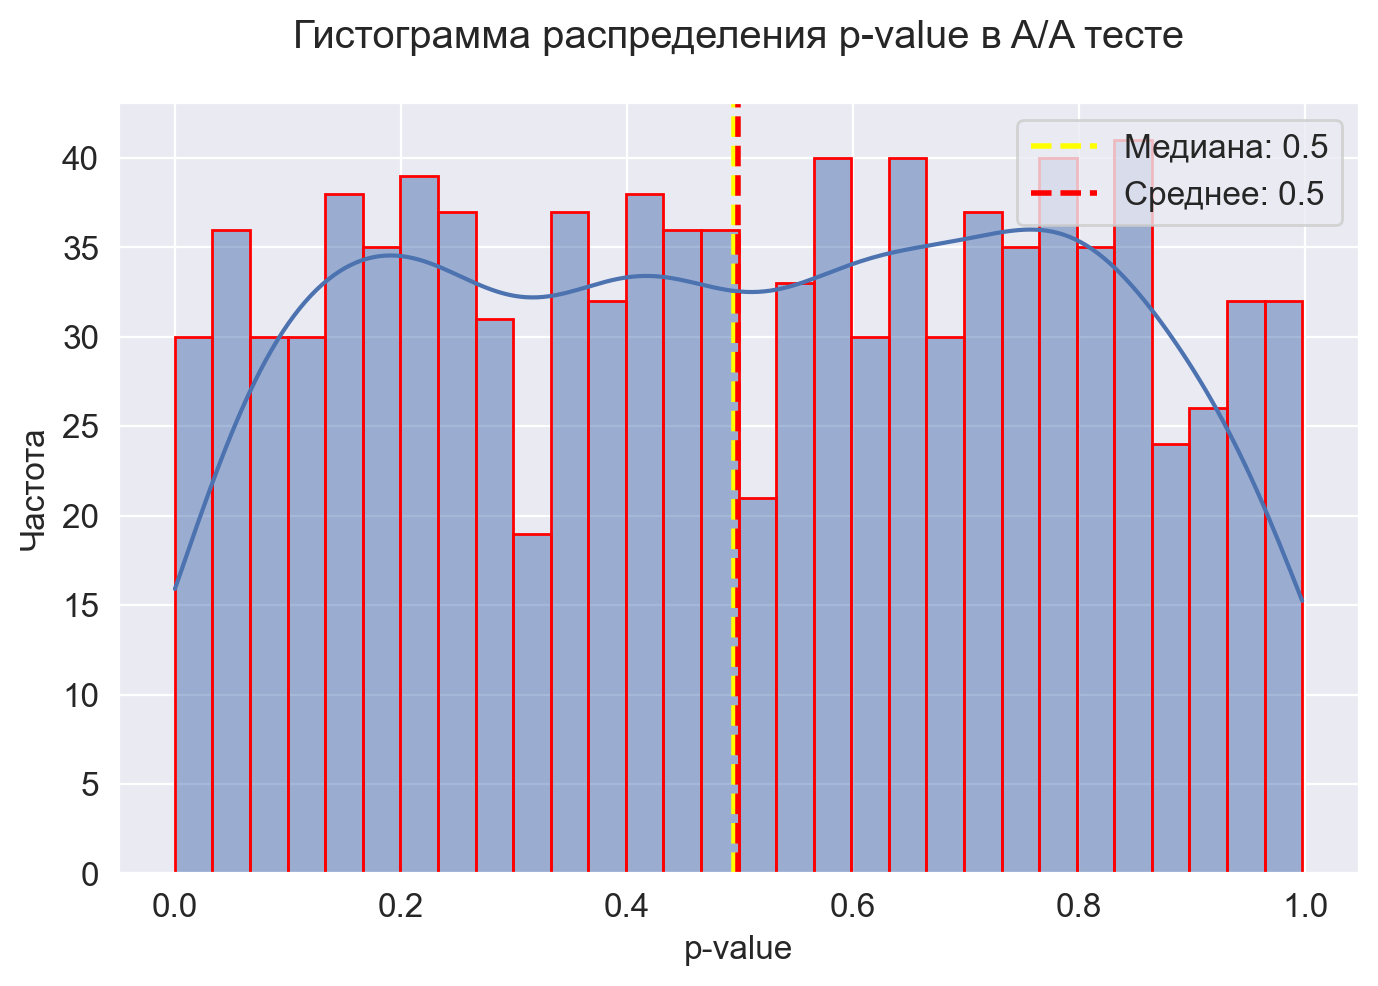

In [155]:
sns.histplot(pvalues_aa, bins=30, kde=True, color='#4C72B0', edgecolor='red')

plt.axvline(np.median(pvalues_aa), color='yellow', linestyle='--', linewidth=2, label=f'Медиана: {np.median(pvalues_aa):.1f}')
plt.axvline(pvalues_aa.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {pvalues_aa.mean():.1f}')

plt.xlabel('p-value')
plt.ylabel('Частота')
plt.title('Гистограмма распределения p-value в A/A тесте', pad=20)
plt.legend()
plt.show()

p-value действительно **распределен равномерно**.\
При большом количестве наблюдений (у нас их 1000) среднее и медиана сходятся к 0.5, что соответствует **свойствам равномерного распределения**\
Это подтверждает, что выполнены статистические предположения о данных **(нормальность, независимость и тд)**